<a href="https://colab.research.google.com/github/Arslan2003/Exploring_ML_Models_for_Regression_and_Classification/blob/Improvements/Exploring_ML_Models_for_Regression_and_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring ML Models for Regression and Classification



## Task 1. Regression

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 17.9 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as skl
import joblib
import optuna
import tensorflow as tf

# Scikit-learn modules
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

# XGBoost
from xgboost import XGBRegressor

# TensorFlow/Keras
from tensorflow import keras
from tensorflow.keras import layers, models


In [ ]:
house_df = pd.read_csv('COMP1816_Housing_Dataset_Regression.csv', index_col=0)
print(house_df.head())

     longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
No.                                                                         
1      -122.12     37.70                  17         2488           617.0   
2      -122.21     38.10                  36         3018           557.0   
3      -122.22     38.11                  43         1939           353.0   
4      -122.20     37.78                  52         2300           443.0   
5      -122.19     37.79                  50          954           217.0   

     population  households  median_income  median_house_value ocean_proximity  
No.                                                                             
1          1287         538         2.9922              179900        NEAR BAY  
2          1445         556         3.8029              129900        NEAR BAY  
3           968         392         3.1848              112700        NEAR BAY  
4          1225         423         3.5398             

In [ ]:
# Check which columns have null values
house_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1 to 1000
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           1000 non-null   float64
 1   latitude            1000 non-null   float64
 2   housing_median_age  1000 non-null   int64  
 3   total_rooms         1000 non-null   int64  
 4   total_bedrooms      988 non-null    float64
 5   population          1000 non-null   int64  
 6   households          1000 non-null   int64  
 7   median_income       1000 non-null   float64
 8   median_house_value  1000 non-null   int64  
 9   ocean_proximity     993 non-null    object 
dtypes: float64(4), int64(5), object(1)
memory usage: 85.9+ KB


In [ ]:
print(house_df['ocean_proximity'].unique())

['NEAR BAY' '<1H OCEAN' 'INLAND' nan 'NEAR OCEAN']


### Data Pre-processing

#### Data Cleaning

In [ ]:
train = house_df.iloc[:810]
test = house_df.iloc[810:]

num_cols = train.select_dtypes(include=['number']).columns
cat_cols = train.select_dtypes(include=['object', 'category']).columns

train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

### **1. Fill Missing Values in Numerical Columns (Using Median of X_train)**
num_imputer = SimpleImputer(strategy='median')

# Fit on X_train and transform both X_train & test
train[num_cols] = num_imputer.fit_transform(train[num_cols])
test[num_cols] = num_imputer.transform(test[num_cols])

### **2. Fill Missing Values in Categorical Columns (Using Most Frequent Category of X_train)**
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit on X_train and transform both X_train & X_test
train[cat_cols] = cat_imputer.fit_transform(train[cat_cols])
test[cat_cols] = cat_imputer.transform(test[cat_cols])

print(train.head())
print(test.head())

print(train.shape)
print(test.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.12     37.70                17.0       2488.0           617.0   
1    -122.21     38.10                36.0       3018.0           557.0   
2    -122.22     38.11                43.0       1939.0           353.0   
3    -122.20     37.78                52.0       2300.0           443.0   
4    -122.19     37.79                50.0        954.0           217.0   

   population  households  median_income  median_house_value ocean_proximity  
0      1287.0       538.0         2.9922            179900.0        NEAR BAY  
1      1445.0       556.0         3.8029            129900.0        NEAR BAY  
2       968.0       392.0         3.1848            112700.0        NEAR BAY  
3      1225.0       423.0         3.5398            158400.0        NEAR BAY  
4       546.0       201.0         2.6667            172800.0        NEAR BAY  
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \


<ipython-input-18-3c15570e2990>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[num_cols] = num_imputer.fit_transform(train[num_cols])
<ipython-input-18-3c15570e2990>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[num_cols] = num_imputer.transform(test[num_cols])
<ipython-input-18-3c15570e2990>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

In [ ]:
Y_train = train['median_house_value']
X_train = train.drop('median_house_value', axis=1)

Y_test = test['median_house_value']
X_test = test.drop('median_house_value', axis=1)

print(X_train.head())
print(Y_train.head())
print(X_test.head())
print(Y_test.head())

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.12     37.70                17.0       2488.0           617.0   
1    -122.21     38.10                36.0       3018.0           557.0   
2    -122.22     38.11                43.0       1939.0           353.0   
3    -122.20     37.78                52.0       2300.0           443.0   
4    -122.19     37.79                50.0        954.0           217.0   

   population  households  median_income ocean_proximity  
0      1287.0       538.0         2.9922        NEAR BAY  
1      1445.0       556.0         3.8029        NEAR BAY  
2       968.0       392.0         3.1848        NEAR BAY  
3      1225.0       423.0         3.5398        NEAR BAY  
4       546.0       201.0         2.6667        NEAR BAY  
0    179900.0
1    129900.0
2    112700.0
3    158400.0
4    172800.0
Name: median_house_value, dtype: float64
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -121

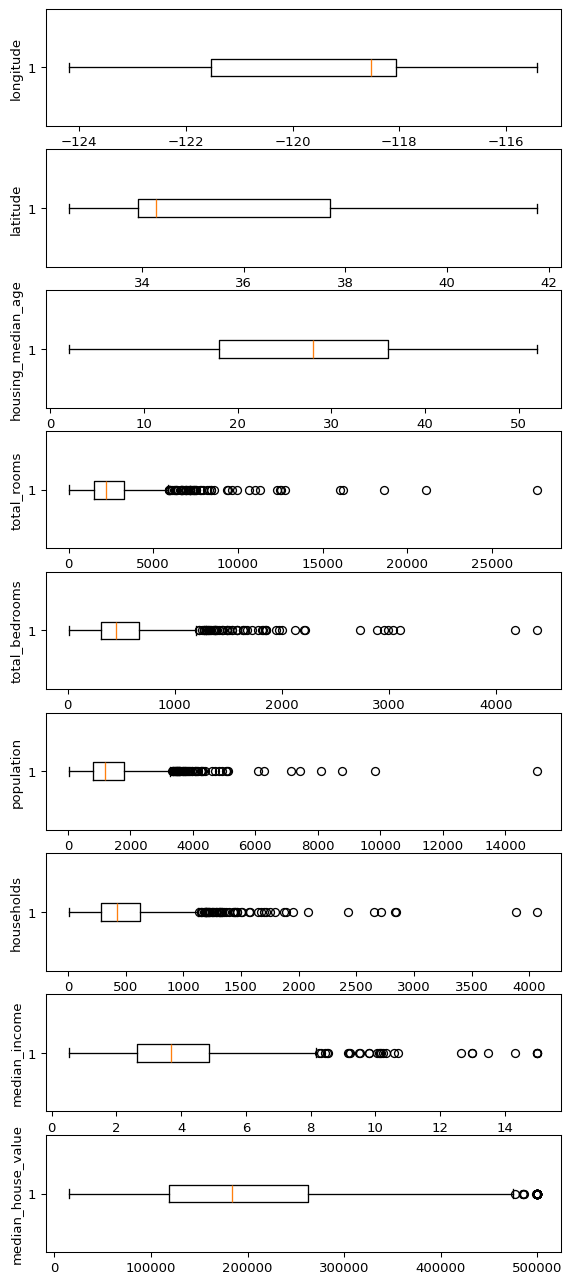

In [ ]:
cleaned_df = pd.concat([train, test], ignore_index=True)
cleaned_df.drop('ocean_proximity', axis=1, inplace=True)

fig, axs = plt.subplots(9,1,dpi=95, figsize=(7,17))
i = 0
for col in cleaned_df.columns: # 10 columns in the df
    axs[i].boxplot(cleaned_df[col], vert=False)
    axs[i].set_ylabel(col)
    i+=1
    if i >= len(axs):
        break
plt.show()

#### Feature Engineering

In [ ]:
# feature extraction - add/extract more features from the original df
X_train_extra = X_train.copy()

# Room density - indicate how spacious each household is
X_train_extra['room_density'] = X_train_extra['total_rooms'] / X_train_extra['households']

# Bedroom density - how many bedrooms each household has (on average)
X_train_extra['bedroom_density'] = X_train_extra['total_bedrooms'] / X_train_extra['households']

# Pop density - how crowded a household is
X_train_extra['pop_density'] = X_train_extra['population'] / X_train_extra['households']

# Income_bedroom - wealthier households tend to have more bedrooms (?)
X_train_extra['income_bedroom'] = X_train_extra['median_income'] * X_train_extra['total_bedrooms']


# Desining the same features but for X_test_extra dataset
X_test_extra = X_train.copy()
X_test_extra['room_density'] = X_test_extra['total_rooms'] / X_test_extra['households']
X_test_extra['bedroom_density'] = X_test_extra['total_bedrooms'] / X_test_extra['households']
X_test_extra['pop_density'] = X_test_extra['population'] / X_test_extra['households']
X_test_extra['income_bedroom'] = X_test_extra['median_income'] * X_test_extra['total_bedrooms']

print(X_train_extra.columns)
print(X_train_extra.head())

print(X_test_extra.columns)
print(X_test_extra.head())

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'room_density', 'bedroom_density', 'pop_density',
       'income_bedroom'],
      dtype='object')
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.12     37.70                17.0       2488.0           617.0   
1    -122.21     38.10                36.0       3018.0           557.0   
2    -122.22     38.11                43.0       1939.0           353.0   
3    -122.20     37.78                52.0       2300.0           443.0   
4    -122.19     37.79                50.0        954.0           217.0   

   population  households  median_income ocean_proximity  room_density  \
0      1287.0       538.0         2.9922        NEAR BAY      4.624535   
1      1445.0       556.0         3.8029        NEAR BAY      5.428058   
2       968.0       392.0         3.1848        NEAR BAY      4.

#### Dimensionality Reduction

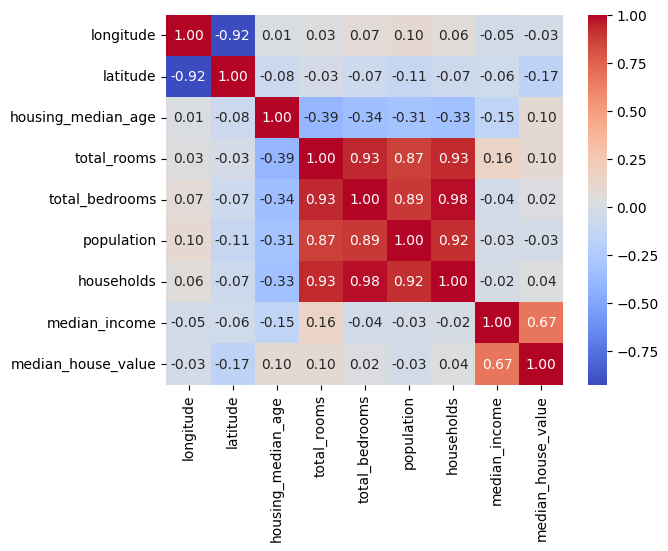

In [ ]:
# Correlation Matrix - to visualise highly correlated columns

corr_matrix = house_df.drop(columns = ['ocean_proximity']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [ ]:
# Randomly remove columns from highly correlated column groups

# Compute the correlation matrix
house_df_reduced = house_df.drop(columns=['ocean_proximity'])
corr_matrix = house_df_reduced.corr().abs()  # Take absolute values to consider both positive & negative correlations

# Set the threshold for high correlation (e.g., 0.85)
threshold = 0.85

# Find pairs of highly correlated columns
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, idx) for col in upper_tri.columns for idx in upper_tri.index if upper_tri.loc[idx, col] > threshold]

# Track columns to drop
columns_to_drop = set()

# Create a set of all columns in the original dataset
remaining_columns = set(house_df_reduced.columns)

# Iterate over all high correlation pairs and drop one column from each pair
for col1, col2 in high_corr_pairs:
    if col1 in remaining_columns and col2 in remaining_columns:
        # Randomly drop one column from the pair
        column_to_drop = np.random.choice([col1, col2])
        columns_to_drop.add(column_to_drop)
        remaining_columns.remove(column_to_drop)

# Drop the selected columns
house_df_reduced = house_df_reduced.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print("Dimensionality reduction complete!")

print(house_df_reduced.head())


Dropped columns: {np.str_('longitude'), np.str_('total_rooms'), np.str_('population'), np.str_('total_bedrooms')}
Dimensionality reduction complete!
     latitude  housing_median_age  households  median_income  \
No.                                                            
1       37.70                  17         538         2.9922   
2       38.10                  36         556         3.8029   
3       38.11                  43         392         3.1848   
4       37.78                  52         423         3.5398   
5       37.79                  50         201         2.6667   

     median_house_value  
No.                      
1                179900  
2                129900  
3                112700  
4                158400  
5                172800  


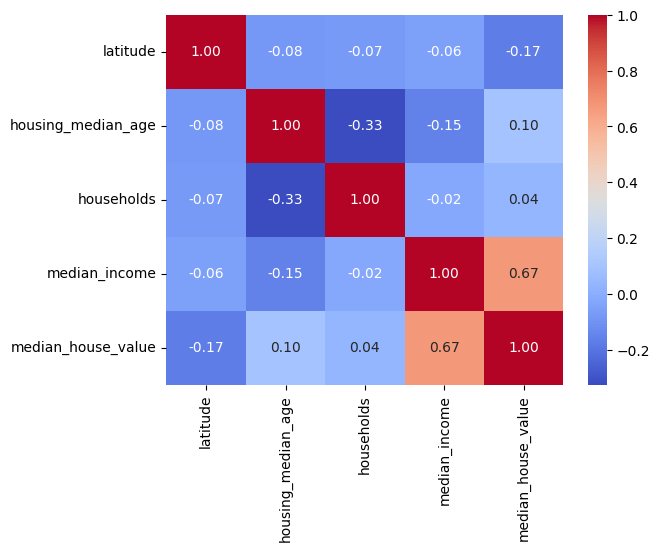

In [ ]:
# Correlation Matrix - to visualise highly correlated columns

corr_matrix = house_df_reduced.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [ ]:
# Separating features (X) and the target (Y)
house_df_reduced['ocean_proximity'] = house_df['ocean_proximity']
train_small = house_df_reduced.iloc[:860]
test_small = house_df_reduced.iloc[860:]

train_small.drop_duplicates(inplace=True)
test_small.drop_duplicates(inplace=True)


X_train_small = train_small.drop('median_house_value', axis=1)
X_test_small = test_small.drop('median_house_value', axis=1)

print(X_train_small.head())
print(X_test_small.head())

print(X_train_small.shape)
print(X_test_small.shape)

     latitude  housing_median_age  households  median_income ocean_proximity
No.                                                                         
1       37.70                  17         538         2.9922        NEAR BAY
2       38.10                  36         556         3.8029        NEAR BAY
3       38.11                  43         392         3.1848        NEAR BAY
4       37.78                  52         423         3.5398        NEAR BAY
5       37.79                  50         201         2.6667        NEAR BAY
     latitude  housing_median_age  households  median_income ocean_proximity
No.                                                                         
861     37.33                  35         449         4.0667       <1H OCEAN
862     37.34                  36         160         5.7910       <1H OCEAN
863     37.31                  31         717         5.2534       <1H OCEAN
864     37.28                  19        1753         3.1509       <1H OCEAN

<ipython-input-25-2a44d84dcd05>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_small.drop_duplicates(inplace=True)
<ipython-input-25-2a44d84dcd05>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_small.drop_duplicates(inplace=True)


#### Feature Standardisation

In [ ]:
def feature_standard(df_train, df_test):
    # Identify numerical and categorical columns
    num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

    # Step 2: Standardize only numerical columns
    scaler = StandardScaler()
    df_train[num_cols] = scaler.fit_transform(df_train[num_cols])  # Fit & transform on train set
    df_test[num_cols] = scaler.transform(df_test[num_cols])  # Transform only on test set

    return df_train, df_test

X_train_stand, X_test_stand = feature_standard(X_train, X_test)

print(X_train.head())
print(X_test.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.600034  1.178060           -0.925229    -0.102848        0.131606   
1  -1.648339  1.372574            0.602918     0.134555       -0.006633   
2  -1.653706  1.377437            1.165920    -0.348761       -0.476646   
3  -1.642972  1.216962            1.889780    -0.187058       -0.269288   
4  -1.637604  1.221825            1.728922    -0.789971       -0.789988   

   population  households  median_income ocean_proximity  
0   -0.164707    0.054262      -0.467144        NEAR BAY  
1   -0.023665    0.100436      -0.038732        NEAR BAY  
2   -0.449470   -0.320260      -0.365365        NEAR BAY  
3   -0.220053   -0.240738      -0.177766        NEAR BAY  
4   -0.826178   -0.810218      -0.639154        NEAR BAY  
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.122347  1.236414           -1.166516    -0.389970       -0.541158   
1  -0.945228  0.200626           -1.166516   

In [ ]:
# Standardising the "extra" features
X_train_extra_stand, X_test_extra_stand = feature_standard(X_train_extra, X_test_extra)

print(X_train_extra_stand.head())
print(X_test_extra_stand.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.600034  1.178060           -0.925229    -0.102848        0.131606   
1  -1.648339  1.372574            0.602918     0.134555       -0.006633   
2  -1.653706  1.377437            1.165920    -0.348761       -0.476646   
3  -1.642972  1.216962            1.889780    -0.187058       -0.269288   
4  -1.637604  1.221825            1.728922    -0.789971       -0.789988   

   population  households  median_income ocean_proximity  room_density  \
0   -0.164707    0.054262      -0.467144        NEAR BAY     -0.412779   
1   -0.023665    0.100436      -0.038732        NEAR BAY      0.011266   
2   -0.449470   -0.320260      -0.365365        NEAR BAY     -0.242905   
3   -0.220053   -0.240738      -0.177766        NEAR BAY      0.016172   
4   -0.826178   -0.810218      -0.639154        NEAR BAY     -0.348536   

   bedroom_density  pop_density  income_bedroom  
0         0.119218    -0.584495       -0.133895  
1   

In [ ]:
# Standardising the "small" features
X_train_small_stand, X_test_small_stand = feature_standard(X_train_small, X_test_small)

print(X_train_small_stand.head())
print(X_test_small_stand.head())

     latitude  housing_median_age  households  median_income ocean_proximity
No.                                                                         
1    1.173807           -0.908214    0.045995      -0.484863        NEAR BAY
2    1.370027            0.614380    0.092005      -0.061220        NEAR BAY
3    1.374932            1.175336   -0.327196      -0.384218        NEAR BAY
4    1.213051            1.896564   -0.247957      -0.198707        NEAR BAY
5    1.217957            1.736291   -0.815412      -0.654958        NEAR BAY
     latitude  housing_median_age  households  median_income ocean_proximity
No.                                                                         
861  0.992305            0.534243   -0.181498       0.076632       <1H OCEAN
862  0.997210            0.614380   -0.920212       0.977690       <1H OCEAN
863  0.982494            0.213697    0.503537       0.696759       <1H OCEAN
864  0.967777           -0.747941    3.151660      -0.401933       <1H OCEAN

#### Standardising the Target Variable

In [ ]:
# Initialize the scaler
y_scaler = StandardScaler()

# Fit on Y_train and transform both Y_train & Y_test
Y_train_stand = y_scaler.fit_transform(Y_train.values.reshape(-1, 1)).ravel()
Y_test_stand = y_scaler.transform(Y_test.values.reshape(-1, 1)).ravel()

print("Y_train_small and Y_test_small have been standardised!")
print(Y_train_stand[:5])
print(Y_test_stand[:5])

Y_train_small and Y_test_small have been standardised!
[-0.21320435 -0.66645371 -0.82237148 -0.40810158 -0.27756576]
[-0.43620304  0.41046675 -0.09717252  0.87550059  0.33069487]


#### Ordinal Encoding

In [ ]:
# Ordinal Encoding of the 'ocean_proximity' column

def oridnal_encoding(df_train, df_test):
    # Identifycategorical columns
    cat_cols = df_train.select_dtypes(include=['object', 'category']).columns

    # Step 1: Apply Ordinal Encoding to categorical columns
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)  # Assign -1 for unknown categories
    df_train_encoded = df_train.copy()
    df_test_encoded = df_test.copy()

    df_train_encoded[cat_cols] = encoder.fit_transform(df_train[cat_cols])  # Fit & transform on train set
    df_test_encoded[cat_cols] = encoder.transform(df_test[cat_cols])  # Transform only on test set

    return df_train_encoded, df_test_encoded

X_train, X_test = oridnal_encoding(X_train, X_test)

print(X_train.head())
print(X_test.head())
print(X_train['ocean_proximity'].unique())
print(X_test['ocean_proximity'].unique())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.600034  1.178060           -0.925229    -0.102848        0.131606   
1  -1.648339  1.372574            0.602918     0.134555       -0.006633   
2  -1.653706  1.377437            1.165920    -0.348761       -0.476646   
3  -1.642972  1.216962            1.889780    -0.187058       -0.269288   
4  -1.637604  1.221825            1.728922    -0.789971       -0.789988   

   population  households  median_income  ocean_proximity  
0   -0.164707    0.054262      -0.467144              2.0  
1   -0.023665    0.100436      -0.038732              2.0  
2   -0.449470   -0.320260      -0.365365              2.0  
3   -0.220053   -0.240738      -0.177766              2.0  
4   -0.826178   -0.810218      -0.639154              2.0  
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.122347  1.236414           -1.166516    -0.389970       -0.541158   
1  -0.945228  0.200626           -1.166

In [ ]:
# Ordinal Encoding of the "extra" dataset

X_train_extra, X_test_extra = oridnal_encoding(X_train_extra, X_test_extra)

print(X_train_extra.head())
print(X_test_extra.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.600034  1.178060           -0.925229    -0.102848        0.131606   
1  -1.648339  1.372574            0.602918     0.134555       -0.006633   
2  -1.653706  1.377437            1.165920    -0.348761       -0.476646   
3  -1.642972  1.216962            1.889780    -0.187058       -0.269288   
4  -1.637604  1.221825            1.728922    -0.789971       -0.789988   

   population  households  median_income  ocean_proximity  room_density  \
0   -0.164707    0.054262      -0.467144              2.0     -0.412779   
1   -0.023665    0.100436      -0.038732              2.0      0.011266   
2   -0.449470   -0.320260      -0.365365              2.0     -0.242905   
3   -0.220053   -0.240738      -0.177766              2.0      0.016172   
4   -0.826178   -0.810218      -0.639154              2.0     -0.348536   

   bedroom_density  pop_density  income_bedroom  
0         0.119218    -0.584495       -0.133895 

In [ ]:
# Ordinal encoding for the "small" dataset

X_train_small, X_test_small = oridnal_encoding(X_train_small, X_test_small)

print(X_train_small.head())
print(X_test_small.head())

     latitude  housing_median_age  households  median_income  ocean_proximity
No.                                                                          
1    1.173807           -0.908214    0.045995      -0.484863              2.0
2    1.370027            0.614380    0.092005      -0.061220              2.0
3    1.374932            1.175336   -0.327196      -0.384218              2.0
4    1.213051            1.896564   -0.247957      -0.198707              2.0
5    1.217957            1.736291   -0.815412      -0.654958              2.0
     latitude  housing_median_age  households  median_income  ocean_proximity
No.                                                                          
861  0.992305            0.534243   -0.181498       0.076632              0.0
862  0.997210            0.614380   -0.920212       0.977690              0.0
863  0.982494            0.213697    0.503537       0.696759              0.0
864  0.967777           -0.747941    3.151660      -0.401933    

In [ ]:
# Ordinal Encoding for all _stand datasets

X_train_stand, X_test_stand = oridnal_encoding(X_train_stand, X_test_stand)

x_train_extra_stand, X_test_extra_stand = oridnal_encoding(X_train_extra_stand, X_test_extra_stand)

X_train_small_stand, X_test_small_stand = oridnal_encoding(X_train_small_stand, X_test_small_stand)

# print(X_train_stand.head())
# print(X_test_stand.head())

### Basic Models
I.e., with default parameters

#### Lasso Regressor

In [ ]:
# The most basic Lasso Regressor Model

# Initialize the Lasso model
lasso_regressor = Lasso(alpha=0.1)  # alpha is the regularization parameter

# Train the model
lasso_regressor.fit(X_train, Y_train)

# Make predictions
y_pred = lasso_regressor.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)
evs = explained_variance_score(Y_test, y_pred)
mape = np.mean(np.abs((Y_test - y_pred) / Y_test)) * 100

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance Score (EVS): {evs:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")


Mean Absolute Error (MAE): 53764.9531
Mean Squared Error (MSE): 5022930825.4830
Root Mean Squared Error (RMSE): 70872.6381
R² Score: 0.6958
Explained Variance Score (EVS): 0.6968
Mean Absolute Percentage Error (MAPE): 32.4068%


#### Random Forest

In [ ]:
# Initialize the model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_regressor.fit(X_train, Y_train)

# Make predictions
y_pred = rf_regressor.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)
evs = explained_variance_score(Y_test, y_pred)
mape = np.mean(np.abs((Y_test - y_pred) / Y_test)) * 100

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance Score (EVS): {evs:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

Mean Absolute Error (MAE): 52980.4200
Mean Squared Error (MSE): 5076905004.3424
Root Mean Squared Error (RMSE): 71252.4035
R² Score: 0.6925
Explained Variance Score (EVS): 0.7053
Mean Absolute Percentage Error (MAPE): 29.3131%


#### XGBoost

In [ ]:
# Initialize XGBoost Regressor with default parameters
xgb_regressor = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

# Train the model
xgb_regressor.fit(X_train, Y_train)

# Make predictions
Y_pred_xgb = xgb_regressor.predict(X_test)

# Compute evaluation metrics
mae = mean_absolute_error(Y_test, Y_pred_xgb)
mse = mean_squared_error(Y_test, Y_pred_xgb)
rmse = mse ** 0.5
r2 = r2_score(Y_test, Y_pred_xgb)

# Print results
print(f"XGBoost - MAE: {mae:.4f}")
print(f"XGBoost - MSE: {mse:.4f}")
print(f"XGBoost - RMSE: {rmse:.4f}")
print(f"XGBoost - R² Score: {r2:.4f}")


XGBoost - MAE: 52240.2344
XGBoost - MSE: 4932249600.0000
XGBoost - RMSE: 70229.9765
XGBoost - R² Score: 0.7012


### Fine-tuning the models: Standardised Features

#### Lasso Regressor

In [ ]:
# Lasso Regressor with standardisation

# Initialize the Lasso model
lasso_regressor = Lasso(alpha=0.1)  # alpha is the regularization parameter

# Train the model
lasso_regressor.fit(X_train_stand, Y_train_stand)

# Make predictions
y_pred = lasso_regressor.predict(X_test_stand)

# Calculate evaluation metrics
mae = mean_absolute_error(Y_test_stand, y_pred)
mse = mean_squared_error(Y_test_stand, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test_stand, y_pred)
evs = explained_variance_score(Y_test_stand, y_pred)
mape = np.mean(np.abs((Y_test_stand - y_pred) / Y_test_stand)) * 100

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance Score (EVS): {evs:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")


Mean Absolute Error (MAE): 0.6541
Mean Squared Error (MSE): 0.6496
Root Mean Squared Error (RMSE): 0.8060
R² Score: 0.5192
Explained Variance Score (EVS): 0.5351
Mean Absolute Percentage Error (MAPE): 98.9848%


#### Random Forest

In [ ]:
# Initialize the model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_regressor.fit(X_train_stand, Y_train_stand)

# Make predictions
y_pred = rf_regressor.predict(X_test_stand)

# Calculate evaluation metrics
mae = mean_absolute_error(Y_test_stand, y_pred)
mse = mean_squared_error(Y_test_stand, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test_stand, y_pred)
evs = explained_variance_score(Y_test_stand, y_pred)
mape = np.mean(np.abs((Y_test_stand - y_pred) / Y_test_stand)) * 100

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance Score (EVS): {evs:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

Mean Absolute Error (MAE): 0.4901
Mean Squared Error (MSE): 0.4260
Root Mean Squared Error (RMSE): 0.6527
R² Score: 0.6847
Explained Variance Score (EVS): 0.6957
Mean Absolute Percentage Error (MAPE): 121.0879%


#### XGBoost

In [ ]:
# Initialize XGBoost Regressor with default parameters
xgb_regressor = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)

# Train the model
xgb_regressor.fit(X_train_stand, Y_train_stand)

# Make predictions
Y_pred_xgb = xgb_regressor.predict(X_test_stand)

# Compute evaluation metrics
mae = mean_absolute_error(Y_test_stand, Y_pred_xgb)
mse = mean_squared_error(Y_test_stand, Y_pred_xgb)
rmse = mse ** 0.5
r2 = r2_score(Y_test_stand, Y_pred_xgb)

# Print results
print(f"XGBoost - MAE: {mae:.4f}")
print(f"XGBoost - MSE: {mse:.4f}")
print(f"XGBoost - RMSE: {rmse:.4f}")
print(f"XGBoost - R² Score: {r2:.4f}")


XGBoost - MAE: 0.4642
XGBoost - MSE: 0.3955
XGBoost - RMSE: 0.6289
XGBoost - R² Score: 0.7072


### Fine-tuning the models: Parameter Optimisation

#### Lasso Regressor

In [ ]:
# Initialize Lasso model
lasso = Lasso()

# Define the distribution for alpha to sample from
# Try a narrower range for alpha to focus more on the regions near the optimal value
param_dist = {
    'alpha': np.logspace(-4, 1, 6)  # Adjusted range for alpha
}

# Initialize RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(estimator=lasso, param_distributions=param_dist, n_iter=10, cv=5,
                                   n_jobs=-1, scoring='neg_mean_squared_error', random_state=42)

# Fit the model
random_search.fit(X_train, Y_train)

# Get the best parameters and model
best_lasso_model = random_search.best_estimator_

# Make predictions using the best model
y_pred = best_lasso_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)
evs = explained_variance_score(Y_test, y_pred)
mape = np.mean(np.abs((Y_test - y_pred) / Y_test)) * 100

# Print the best alpha and evaluation results
print(f"Best Alpha: {random_search.best_params_['alpha']}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Explained Variance Score (EVS): {evs:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Alpha: 10.0
Mean Absolute Error (MAE): 53761.4055
Mean Squared Error (MSE): 5021922729.6427
Root Mean Squared Error (RMSE): 70865.5257
R² Score: 0.6958
Explained Variance Score (EVS): 0.6968
Mean Absolute Percentage Error (MAPE): 32.3994%


#### Random Forest

In [ ]:
# Define a more conservative parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Max depth
    'min_samples_split': [2, 5, 10],  # Min samples to split a node
    'min_samples_leaf': [1, 2, 4],  # Min samples at a leaf node
    'max_features': ['sqrt', 'log2', None],  # Features to consider for each split
    'bootstrap': [True, False]  # Whether to use bootstrap samples
}

# Initialize RandomForestRegressor with a random seed for reproducibility
rf = RandomForestRegressor(random_state=42)

# RandomizedSearchCV with cross-validation to tune hyperparameters
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=5, verbose=2, random_state=42, n_jobs=-1)

# Fit the model
random_search.fit(X_train, Y_train)

# Get the best hyperparameters
best_params = random_search.best_params_
print("Best Hyperparameters: ", best_params)

# Evaluate the optimized model
best_rf_model = random_search.best_estimator_
Y_pred = best_rf_model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = mse ** 0.5
r2 = r2_score(Y_test, Y_pred)

# Print evaluation metrics
print(f"Optimized Random Forest - MAE: {mae:.4f}")
print(f"Optimized Random Forest - MSE: {mse:.4f}")
print(f"Optimized Random Forest - RMSE: {rmse:.4f}")
print(f"Optimized Random Forest - R² Score: {r2:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Optimized Random Forest - MAE: 57803.9929
Optimized Random Forest - MSE: 6019924841.3540
Optimized Random Forest - RMSE: 77588.1746
Optimized Random Forest - R² Score: 0.6354


#### XGBoost

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 15.9 MB/s eta 0:00:00


In [ ]:
# Same as above but with cross-validation

# Define the objective function to minimize
def objective(trial):
    # Define the hyperparameter search space
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }

    # Initialize XGBoost Regressor with suggested hyperparameters
    model = XGBRegressor(**param, objective="reg:squarederror", random_state=42)

    # Use cross-validation to evaluate the model (5-fold cross-validation)
    # 'neg_mean_absolute_error' is used to return negative values (to minimize)
    cv_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='neg_mean_absolute_error')

    # Return the mean of the negative MAE scores
    mean_mae = np.mean(cv_scores)  # This will be negative, so we return the positive value
    return -mean_mae  # Optuna minimizes the objective function, so we return negative MAE

# Create a study object to optimize the hyperparameters
study = optuna.create_study(direction='minimize')

# Perform optimization
study.optimize(objective, n_trials=200)  # Number of trials you want to run

# Print the best hyperparameters and the best score
print("Best Hyperparameters: ", study.best_params)
print("Best MAE: ", study.best_value)

# Train the final model with the best hyperparameters
best_model = XGBRegressor(**study.best_params, objective="reg:squarederror", random_state=42)
best_model.fit(X_train, Y_train)

# Predict and evaluate the final model
Y_pred_best = best_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred_best)
mse = mean_squared_error(Y_test, Y_pred_best)
rmse = mse ** 0.5
r2 = r2_score(Y_test, Y_pred_best)

# Print final evaluation metrics
print(f"Fine-Tuned XGBoost - MAE: {mae:.4f}")
print(f"Fine-Tuned XGBoost - MSE: {mse:.4f}")
print(f"Fine-Tuned XGBoost - RMSE: {rmse:.4f}")
print(f"Fine-Tuned XGBoost - R² Score: {r2:.4f}")


[I 2025-03-21 16:14:42,403] A new study created in memory with name: no-name-6d646677-cb07-4600-8f9b-7ec7f6f38f82
[I 2025-03-21 16:14:47,226] Trial 0 finished with value: 50971.084375 and parameters: {'max_depth': 6, 'learning_rate': 0.15605080009156852, 'n_estimators': 76, 'subsample': 0.8298211425206895, 'colsample_bytree': 0.773071152640792, 'min_child_weight': 7}. Best is trial 0 with value: 50971.084375.
[I 2025-03-21 16:15:07,129] Trial 1 finished with value: 51552.5109375 and parameters: {'max_depth': 11, 'learning_rate': 0.13929778347116054, 'n_estimators': 102, 'subsample': 0.6049457041381564, 'colsample_bytree': 0.6271536300041829, 'min_child_weight': 5}. Best is trial 0 with value: 50971.084375.
[I 2025-03-21 16:15:17,589] Trial 2 finished with value: 50132.63984375 and parameters: {'max_depth': 3, 'learning_rate': 0.0918170464252793, 'n_estimators': 341, 'subsample': 0.5740295011450384, 'colsample_bytree': 0.6250893616417781, 'min_child_weight': 5}. Best is trial 2 with val

Best Hyperparameters:  {'max_depth': 14, 'learning_rate': 0.047522747341973474, 'n_estimators': 189, 'subsample': 0.7544979350755433, 'colsample_bytree': 0.8544698667239704, 'min_child_weight': 7}
Best MAE:  48335.1625
Fine-Tuned XGBoost - MAE: 52239.5859
Fine-Tuned XGBoost - MSE: 4996710912.0000
Fine-Tuned XGBoost - RMSE: 70687.4169
Fine-Tuned XGBoost - R² Score: 0.6973


## Task 2. Classification

In [ ]:
titanic = pd.read_csv('COMP1816_Titanic_Dataset_Classification.csv', index_col=0)
print(titanic.head())

             Pclass                                          Name     Sex  \
PassengerId                                                                 
1               3.0                       Braund, Mr. Owen Harris    male   
2               1.0                                           NaN  female   
3               3.0                        Heikkinen, Miss. Laina  female   
4               1.0  Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   
5               3.0                      Allen, Mr. William Henry    male   

              Age  SibSp  Parch        Ticket No.     Fare Embarked  Survival  
PassengerId                                                                    
1            22.0    1.0    0.0         A/5 21171   7.2500        S       0.0  
2            38.0    1.0    0.0          PC 17599  71.2833        C       1.0  
3            26.0    0.0    0.0  STON/O2. 3101282   7.9250        S       1.0  
4            35.0    1.0    0.0            113803  53.1000  

In [ ]:
# Check which columns have null values
titanic.info()
print(len(titanic))

<class 'pandas.core.frame.DataFrame'>
Index: 890 entries, 1 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      880 non-null    float64
 1   Name        885 non-null    object 
 2   Sex         890 non-null    object 
 3   Age         715 non-null    float64
 4   SibSp       888 non-null    float64
 5   Parch       888 non-null    float64
 6   Ticket No.  888 non-null    object 
 7   Fare        888 non-null    float64
 8   Embarked    884 non-null    object 
 9   Survival    886 non-null    float64
dtypes: float64(6), object(4)
memory usage: 76.5+ KB
890


In [ ]:
print(titanic['Sex'].unique())
print(titanic['Embarked'].unique())
print(titanic['Pclass'].unique())

['male' 'female']
['S' 'C' nan 'Q']
[ 3.  1.  2. nan]


In [ ]:
print(titanic.isnull().sum())
print(titanic.shape)
print(f'{round(175 / 890 * 100, 2)}% of the Age column is missing')

Pclass         10
Name            5
Sex             0
Age           175
SibSp           2
Parch           2
Ticket No.      2
Fare            2
Embarked        6
Survival        4
dtype: int64
(890, 10)
19.66% of the Age column is missing


In [ ]:
print(titanic.duplicated().sum())

0


### Data Pre-processing

In [ ]:
# Drop Name and Ticket column as they cannot be used by the ML algorithms and
# Do not provide any significant information

titanic.drop(['Name', 'Ticket No.'], axis=1, inplace=True)

train = titanic.iloc[:750]
test = titanic.iloc[750:]

train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

print(train.head())
print(test.head())

print(train.shape)
print(test.shape)

sur_imputer = SimpleImputer(strategy='most_frequent')

# Impute missing values in 'Survival' column
train['Survival'] = sur_imputer.fit_transform(train[['Survival']])
test['Survival'] = sur_imputer.transform(test[['Survival']])

print(train.isnull().sum())
print(test.isnull().sum())

train['Survival'] = train['Survival'].astype('object')
test['Survival'] = test['Survival'].astype('object')

print(train.info())
print(test.info())


   Pclass     Sex   Age  SibSp  Parch     Fare Embarked  Survival
0     3.0    male  22.0    1.0    0.0   7.2500        S       0.0
1     1.0  female  38.0    1.0    0.0  71.2833        C       1.0
2     3.0  female  26.0    0.0    0.0   7.9250        S       1.0
3     1.0  female  35.0    1.0    0.0  53.1000        S       1.0
4     3.0    male  35.0    0.0    0.0   8.0500        S       0.0
   Pclass     Sex    Age  SibSp  Parch     Fare Embarked  Survival
0     3.0    male   6.00    0.0    1.0  12.4750        S       1.0
1     3.0    male  33.00    0.0    0.0   9.5000        S       0.0
2     3.0    male  23.00    0.0    0.0   7.8958        S       0.0
3     2.0  female  48.00    1.0    2.0  65.0000        S       1.0
4     2.0    male   0.67    1.0    1.0  14.5000        S       1.0
(750, 8)
(140, 8)
Pclass        7
Sex           0
Age         152
SibSp         2
Parch         2
Fare          2
Embarked      5
Survival      0
dtype: int64
Pclass       3
Sex          0
Age         2

<ipython-input-7-b54f6b520315>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Survival'] = sur_imputer.fit_transform(train[['Survival']])
<ipython-input-7-b54f6b520315>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Survival'] = sur_imputer.transform(test[['Survival']])
<ipython-input-7-b54f6b520315>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

#### Data Cleaning

In [ ]:
num_cols = train.select_dtypes(include=['number']).columns
cat_cols = train.select_dtypes(include=['object', 'category']).columns

num_imputer = SimpleImputer(strategy='median')

train[num_cols] = num_imputer.fit_transform(train[num_cols])
test[num_cols] = num_imputer.transform(test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')

train[cat_cols] = cat_imputer.fit_transform(train[cat_cols])
test[cat_cols] = cat_imputer.transform(test[cat_cols])

# Print confirmation
print("Missing values filled successfully!")
print(f'X_train:\n{train.isnull().sum()}\n')
print(f'X_test:\n{test.isnull().sum()}\n')

Missing values filled successfully!
X_train:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survival    0
dtype: int64

X_test:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survival    0
dtype: int64



<ipython-input-8-9a9a045ad1d2>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[num_cols] = num_imputer.fit_transform(train[num_cols])
<ipython-input-8-9a9a045ad1d2>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[num_cols] = num_imputer.transform(test[num_cols])
<ipython-input-8-9a9a045ad1d2>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

In [ ]:
Y_train = train['Survival']
X_train = train.drop('Survival', axis=1)

Y_test = test['Survival']
X_test = test.drop('Survival', axis=1)

# print(X_train.head())
print(Y_train.head())
# print(X_test.head())
print(Y_test.head())

# print(X_train.shape)
print(Y_train.shape)
# print(X_test.shape)
print(Y_test.shape)

0    0.0
1    1.0
2    1.0
3    1.0
4    0.0
Name: Survival, dtype: object
0    1.0
1    0.0
2    0.0
3    1.0
4    1.0
Name: Survival, dtype: object
(750,)
(140,)


In [ ]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())
print(Y_train.isnull().sum())
print(Y_test.isnull().sum())

print('\nDuplicates:')
print(X_train.duplicated().sum())
print(X_test.duplicated().sum())

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
0
0

Duplicates:
105
6


#### Label Encoding

In [ ]:
X_train.info()
Y_train.info()
# To encode?


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    750 non-null    float64
 1   Sex       750 non-null    object 
 2   Age       750 non-null    float64
 3   SibSp     750 non-null    float64
 4   Parch     750 non-null    float64
 5   Fare      750 non-null    float64
 6   Embarked  750 non-null    object 
dtypes: float64(5), object(2)
memory usage: 41.1+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 750 entries, 0 to 749
Series name: Survival
Non-Null Count  Dtype 
--------------  ----- 
750 non-null    object
dtypes: object(1)
memory usage: 6.0+ KB


In [ ]:
# List of columns to encode
col_to_encode = ['Sex', 'Embarked']

# Initialize One-Hot Encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # Ignore unknown categories in X_test

# Fit on X_train and Transform Both X_train and X_test
X_train_encoded = ohe.fit_transform(X_train[col_to_encode])
X_test_encoded = ohe.transform(X_test[col_to_encode])

# Convert to DataFrame
# Use `col_to_encode` to generate proper feature names for the encoded columns
X_train_encoded = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(col_to_encode))
X_test_encoded = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(col_to_encode))

X_train.drop(col_to_encode, axis=1, inplace=True)
X_test.drop(col_to_encode, axis=1, inplace=True)

X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)


# Output the encoded data
# print("Encoded X_train:")
# print(X_train.head())
# print("\nEncoded X_test:")
# print(X_test.head())
# print(X_train.info())

print(Y_train.info())
print(Y_test.info())

<class 'pandas.core.series.Series'>
RangeIndex: 750 entries, 0 to 749
Series name: Survival
Non-Null Count  Dtype 
--------------  ----- 
750 non-null    object
dtypes: object(1)
memory usage: 6.0+ KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 140 entries, 0 to 139
Series name: Survival
Non-Null Count  Dtype 
--------------  ----- 
140 non-null    object
dtypes: object(1)
memory usage: 1.2+ KB
None


#### Feature Standardisation

In [ ]:
# List of numerical columns to standardize
continuous_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Initialize StandardScaler
scaler = MinMaxScaler()

# Standardize the numerical columns
X_train_continuous = scaler.fit_transform(X_train[continuous_cols])
X_test_continuous = scaler.transform(X_test[continuous_cols])
joblib.dump(scaler, 'minmax_scaler.pkl')

# Convert the scaled continuous features back to DataFrame
X_train_continuous_df = pd.DataFrame(X_train_continuous, columns=continuous_cols)
X_test_continuous_df = pd.DataFrame(X_test_continuous, columns=continuous_cols)

# Drop the original numerical columns from X_train and X_test
X_train.drop(continuous_cols, axis=1, inplace=True)
X_test.drop(continuous_cols, axis=1, inplace=True)

# Combine the standardized continuous features with the encoded categorical features
X_train_final = pd.concat([X_train, X_train_continuous_df], axis=1)
X_test_final = pd.concat([X_test, X_test_continuous_df], axis=1)

# Output the final data
# print("Final X_train:")
# print(X_train_final.head())
# print("\nFinal X_test:")
# print(X_test_final.head())
print(X_train_final.info())


# For when I might need the scaler again
# # Load the scaler
# scaler = joblib.load('minmax_scaler.pkl')

# # Use the loaded scaler to transform new data
# X_new_scaled = scaler.transform(X_new[['sibsp', 'parch']])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      750 non-null    float64
 1   Sex_female  750 non-null    float64
 2   Sex_male    750 non-null    float64
 3   Embarked_C  750 non-null    float64
 4   Embarked_Q  750 non-null    float64
 5   Embarked_S  750 non-null    float64
 6   Age         750 non-null    float64
 7   Fare        750 non-null    float64
 8   SibSp       750 non-null    float64
 9   Parch       750 non-null    float64
dtypes: float64(10)
memory usage: 58.7 KB
None


In [ ]:
Y_train = pd.to_numeric(Y_train, errors="coerce")
Y_test = pd.to_numeric(Y_test, errors="coerce")

In [ ]:
print(X_train_final.info())
print(X_test_final.info())
print(Y_train.info())
print(Y_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      750 non-null    float64
 1   Sex_female  750 non-null    float64
 2   Sex_male    750 non-null    float64
 3   Embarked_C  750 non-null    float64
 4   Embarked_Q  750 non-null    float64
 5   Embarked_S  750 non-null    float64
 6   Age         750 non-null    float64
 7   Fare        750 non-null    float64
 8   SibSp       750 non-null    float64
 9   Parch       750 non-null    float64
dtypes: float64(10)
memory usage: 58.7 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      140 non-null    float64
 1   Sex_female  140 non-null    float64
 2   Sex_male    140 non-null    float64
 3   Embarked_C  140 non-null    float64
 4   

In [ ]:
print(X_train_final.shape)
print(X_test_final.shape)
print(Y_train.shape)
print(Y_test.shape)

(750, 10)
(140, 10)
(750,)
(140,)


### Basic Models

#### KNN

In [ ]:
# Initialize the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune the number of neighbors

# Train the model
knn.fit(X_train_final, Y_train)

# Make predictions on the test set
Y_pred_final = knn.predict(X_test_final)

# Evaluate the model with different metrics
accuracy = accuracy_score(Y_test, Y_pred_final)
f1 = f1_score(Y_test, Y_pred_final)
precision = precision_score(Y_test, Y_pred_final)
recall = recall_score(Y_test, Y_pred_final)
roc_auc = roc_auc_score(Y_test, Y_pred_final)

# Print the evaluation metrics
print(f"Accuracy: {accuracy}")
print(f"F1-Score: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"ROC AUC: {roc_auc}")



Accuracy: 0.8071428571428572
F1-Score: 0.7157894736842105
Precision: 0.7555555555555555
Recall: 0.68
ROC AUC: 0.778888888888889


#### SVM

In [ ]:
# Initialize the SVM model
svm = SVC(kernel='linear')  # You can try different kernels like 'rbf', 'poly', etc.

# Train the model
svm.fit(X_train_final, Y_train)

# Make predictions on the test set
Y_pred_svm = svm.predict(X_test_final)

# Evaluate the model with different metrics
accuracy = accuracy_score(Y_test, Y_pred_svm)
f1 = f1_score(Y_test, Y_pred_svm)
precision = precision_score(Y_test, Y_pred_svm)
recall = recall_score(Y_test, Y_pred_svm)
roc_auc = roc_auc_score(Y_test, Y_pred_svm)

# Print the evaluation metrics
print(f"Accuracy: {accuracy}")
print(f"F1-Score: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"ROC AUC: {roc_auc}")


Accuracy: 0.7928571428571428
F1-Score: 0.7010309278350515
Precision: 0.723404255319149
Recall: 0.68
ROC AUC: 0.7677777777777779


#### Neural Networks

In [ ]:
# Define the neural network model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train_final.shape[1],)),  # Hidden layer with 16 neurons
    layers.Dense(8, activation='relu'),  # Another hidden layer with 8 neurons
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_final, Y_train, epochs=50, batch_size=32, validation_data=(X_test_final, Y_test))

# Evaluate the model
eval_results = model.evaluate(X_test_final, Y_test)
print(f'Loss: {eval_results[0]:.4f}, Accuracy: {eval_results[1]:.4f}')

# Make predictions on the test set
Y_pred = model.predict(X_test_final)

# Convert predictions to binary values (0 or 1)
Y_pred_binary = (Y_pred > 0.5).astype(int)

# Compute additional evaluation metrics
f1 = f1_score(Y_test, Y_pred_binary)
precision = precision_score(Y_test, Y_pred_binary)
recall = recall_score(Y_test, Y_pred_binary)
roc_auc = roc_auc_score(Y_test, Y_pred_binary)

# Print additional metrics
print(f'F1-Score: {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.4176 - loss: 0.6976 - val_accuracy: 0.4929 - val_loss: 0.6845
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6300 - loss: 0.6767 - val_accuracy: 0.7500 - val_loss: 0.6659
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7544 - loss: 0.6612 - val_accuracy: 0.7571 - val_loss: 0.6494
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7510 - loss: 0.6456 - val_accuracy: 0.7929 - val_loss: 0.6334
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7969 - loss: 0.6219 - val_accuracy: 0.7929 - val_loss: 0.6199
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8017 - loss: 0.6141 - val_accuracy: 0.7929 - val_loss: 0.6047
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7643 - loss: 0.6034 - val_accuracy: 0.7929 - val_loss: 0.5822
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7971 - loss: 0.5700 - val_accuracy: 0.7929 - v

### Model Optimisation

#### KNN

In [ ]:
# Objective function for Optuna with 5-fold cross-validation
def objective(trial):
    # Define the hyperparameters to optimize
    n_neighbors = trial.suggest_int('n_neighbors', 1, 20)  # K value between 1 and 20
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])  # Weighting strategy
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'chebyshev'])  # Distance metric
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])  # Algorithm type

    # Initialize the KNN model
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric,
        algorithm=algorithm
    )

    # Perform 5-fold cross-validation
    f1_scores = cross_val_score(model, X_train_final, Y_train, cv=5, scoring='f1')

    # Return the mean F1-score
    return f1_scores.mean()

# Create the Optuna study and optimize
study = optuna.create_study(direction='maximize')  # Maximizing the F1-score
study.optimize(objective, n_trials=100)  # Run 100 trials

# Print the best hyperparameters and evaluation metrics
print("Best Hyperparameters:", study.best_params)
print("Best F1-Score:", study.best_value)

# Train the best model on the entire training set
best_knn = KNeighborsClassifier(**study.best_params)
best_knn.fit(X_train_final, Y_train)

# Evaluate the best model on the test set
Y_pred_best_knn = best_knn.predict(X_test_final)

# Print the evaluation metrics for the best model
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_best_knn)}")
print(f"F1-Score: {f1_score(Y_test, Y_pred_best_knn)}")
print(f"Precision: {precision_score(Y_test, Y_pred_best_knn)}")
print(f"Recall: {recall_score(Y_test, Y_pred_best_knn)}")
print(f"ROC AUC: {roc_auc_score(Y_test, Y_pred_best_knn)}")


[I 2025-03-21 16:24:19,499] A new study created in memory with name: no-name-28502798-5b95-4210-843d-9e623398c91a
[I 2025-03-21 16:24:19,691] Trial 0 finished with value: 0.6839587628865978 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'metric': 'chebyshev', 'algorithm': 'auto'}. Best is trial 0 with value: 0.6839587628865978.
[I 2025-03-21 16:24:19,889] Trial 1 finished with value: 0.6767565386389418 and parameters: {'n_neighbors': 1, 'weights': 'uniform', 'metric': 'chebyshev', 'algorithm': 'auto'}. Best is trial 0 with value: 0.6839587628865978.
[I 2025-03-21 16:24:20,234] Trial 2 finished with value: 0.7012232482211098 and parameters: {'n_neighbors': 6, 'weights': 'uniform', 'metric': 'chebyshev', 'algorithm': 'ball_tree'}. Best is trial 2 with value: 0.7012232482211098.
[I 2025-03-21 16:24:20,592] Trial 3 finished with value: 0.6850869223544744 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'metric': 'chebyshev', 'algorithm': 'brute'}. Best is trial 2 with v

Best Hyperparameters: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'euclidean', 'algorithm': 'kd_tree'}
Best F1-Score: 0.7281875702517718
Accuracy: 0.8
F1-Score: 0.7142857142857143
Precision: 0.7291666666666666
Recall: 0.7
ROC AUC: 0.7777777777777778


#### SVM

In [ ]:
# Objective function for Optuna to fine-tune SVM
def objective(trial):
    # Define the hyperparameters to optimize
    C = trial.suggest_float('C', 1e-3, 1e3, log=True)  # Regularization parameter
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])  # Kernel type
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])  # Kernel coefficient for rbf/poly kernels
    degree = trial.suggest_int('degree', 1, 5) if kernel == 'poly' else 3  # Degree for poly kernel
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weight

    # Initialize the SVM model with the selected hyperparameters
    model = SVC(C=C, kernel=kernel, gamma=gamma, degree=degree, class_weight=class_weight)

    # Perform cross-validation to evaluate the model
    score = cross_val_score(model, X_train_final, Y_train, cv=3, scoring='accuracy').mean()

    # Return the score (we are maximizing the accuracy)
    return score

# Create the Optuna study and optimize
study = optuna.create_study(direction='maximize')  # We are maximizing the accuracy score
study.optimize(objective, n_trials=100, timeout = 60)  # Run 100 trials

# Print the best hyperparameters and evaluation metrics
print("Best Hyperparameters:", study.best_params)
print("Best Accuracy:", study.best_value)

# Get the best model based on the study's best hyperparameters
best_svm = SVC(**study.best_params)
best_svm.fit(X_train_final, Y_train)

# Evaluate the best model on the test set
Y_pred_best_svm = best_svm.predict(X_test_final)

# Print the evaluation metrics for the best model
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_best_svm)}")
print(f"F1-Score: {f1_score(Y_test, Y_pred_best_svm)}")
print(f"Precision: {precision_score(Y_test, Y_pred_best_svm)}")
print(f"Recall: {recall_score(Y_test, Y_pred_best_svm)}")
print(f"ROC AUC: {roc_auc_score(Y_test, Y_pred_best_svm)}")


[I 2025-03-21 17:04:02,511] A new study created in memory with name: no-name-c62fe026-d8dc-420b-91c4-ab34d065e268


#### Neural Networks

In [ ]:
# Define the Optuna objective function to optimize the neural network
def objective(trial):
    # Define the model
    model = models.Sequential()

    # Hyperparameters to optimize
    num_layers = trial.suggest_int('num_layers', 1, 3)  # Number of layers
    for i in range(num_layers):
        num_neurons = trial.suggest_int(f'n_neurons_l{i+1}', 32, 128, log=True)  # Neurons per layer
        model.add(layers.Dense(num_neurons, activation='relu'))  # Hidden layers

    # Add output layer
    model.add(layers.Dense(1, activation='sigmoid'))  # Binary output for classification

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
        ),
        loss='binary_crossentropy',  # Use binary crossentropy for binary classification
        metrics=['accuracy']
    )

    # Train the model
    model.fit(X_train_final, Y_train, epochs=10, batch_size=trial.suggest_int('batch_size', 16, 64), verbose=0)

    # Make predictions on the test set
    Y_pred_proba = model.predict(X_test_final)  # Predicted probabilities
    Y_pred = (Y_pred_proba > 0.5).astype('int32')  # Convert probabilities to binary class predictions

    # Evaluate the model using different metrics
    accuracy = accuracy_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    roc_auc = roc_auc_score(Y_test, Y_pred_proba)

    # Print evaluation metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    return accuracy  # Optuna will maximize this value

# Create Optuna study
study = optuna.create_study(direction='maximize')  # We are maximizing accuracy
study.optimize(objective, n_trials=50)  # Run optimization for 50 trials

# Get the best hyperparameters
best_params = study.best_params
print(f"Best Hyperparameters: {best_params}")
print(f"Best Accuracy: {study.best_value}")


[I 2025-03-21 16:41:05,136] A new study created in memory with name: no-name-aee9f2b0-9c86-40fd-8335-414378dc1d2f


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[I 2025-03-21 16:41:13,991] Trial 0 finished with value: 0.6428571428571429 and parameters: {'num_layers': 3, 'n_neurons_l1': 100, 'n_neurons_l2': 71, 'n_neurons_l3': 87, 'learning_rate': 1.3318292235907049e-05, 'batch_size': 19}. Best is trial 0 with value: 0.6428571428571429.


Accuracy: 0.6429
F1-Score: 0.0000
Precision: 0.0000
Recall: 0.0000
ROC AUC: 0.7774
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


[I 2025-03-21 16:41:20,959] Trial 1 finished with value: 0.8285714285714286 and parameters: {'num_layers': 1, 'n_neurons_l1': 89, 'learning_rate': 0.02709027392248346, 'batch_size': 16}. Best is trial 1 with value: 0.8285714285714286.


...

Accuracy: 0.8143
F1-Score: 0.7234
Precision: 0.7727
Recall: 0.6800
ROC AUC: 0.8471
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


[I 2025-03-21 16:43:46,785] Trial 48 finished with value: 0.8214285714285714 and parameters: {'num_layers': 1, 'n_neurons_l1': 128, 'learning_rate': 0.003376987320569426, 'batch_size': 18}. Best is trial 1 with value: 0.8285714285714286.


Accuracy: 0.8214
F1-Score: 0.7312
Precision: 0.7907
Recall: 0.6800
ROC AUC: 0.8320
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


[I 2025-03-21 16:43:49,757] Trial 49 finished with value: 0.8214285714285714 and parameters: {'num_layers': 2, 'n_neurons_l1': 51, 'n_neurons_l2': 58, 'learning_rate': 0.013442773531854309, 'batch_size': 29}. Best is trial 1 with value: 0.8285714285714286.


Accuracy: 0.8214
F1-Score: 0.6988
Precision: 0.8788
Recall: 0.5800
ROC AUC: 0.8562
Best Hyperparameters: {'num_layers': 1, 'n_neurons_l1': 89, 'learning_rate': 0.02709027392248346, 'batch_size': 16}
Best Accuracy: 0.8285714285714286
